# Lecture 7: Vision Transformer

<div class="alert alert-success">This notebook implements a Vision Transformer (ViT) from scratch for image classification on CIFAR-10, following [Dosovitskiy et al. (2020)](https://arxiv.org/abs/2010.11929).</div>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


## CIFAR-10

In [2]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

train_data = datasets.CIFAR10('./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10('./data', train=False, transform=test_transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=256)

/home/momo/.local/share/mamba/envs/info8010/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Patch embedding

Split each image into a grid of patches and project each patch into an embedding vector with a linear layer. For a 32x32 image with patch size 4, we get 8x8 = 64 patches.

In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) -> (B, n_patches, embed_dim)
        x = self.proj(x)             # (B, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2)  # (B, n_patches, embed_dim)
        return x

Let's visualize the patches:

(np.float64(-0.5), np.float64(38.5), np.float64(38.5), np.float64(-0.5))

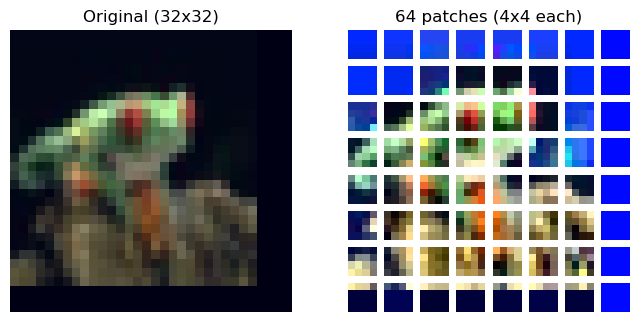

In [ ]:
patch_embed = PatchEmbedding()
x = next(iter(train_loader))[0][:1]  # one image

# Show original image
img = x[0].permute(1, 2, 0).cpu()
img = (img - img.min()) / (img.max() - img.min())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (32x32)')
axes[0].axis('off')

# Show patches as a grid
patches = x.unfold(2, 4, 4).unfold(3, 4, 4)  # (1, 3, 8, 8, 4, 4)
patches = patches[0].permute(1, 2, 3, 4, 0)   # (8, 8, 4, 4, 3)
grid = patches.reshape(8, 8, 4, 4, 3)

# Add borders between patches
bordered = torch.ones(8*5-1, 8*5-1, 3)
for i in range(8):
    for j in range(8):
        p = grid[i, j]
        p = (p - p.min()) / (p.max() - p.min() + 1e-8)
        bordered[i*5:i*5+4, j*5:j*5+4] = p

axes[1].imshow(bordered.cpu())
axes[1].set_title('64 patches (4x4 each)')
axes[1].axis('off')

## Transformer encoder

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = embed_dim // n_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0) 

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, n_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, n_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

## Vision Transformer

In [ ]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, n_classes=10,
                 embed_dim=128, depth=6, n_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, n_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                                
        cls = self.cls_token.expand(B, -1, -1)                   
        x = x + self.pos_embed                                  
        x = self.norm(self.blocks(x))                              
        return self.head(x[:, 0])                                   

model = ViT().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')

Parameters: 1.2M


/home/momo/.local/share/mamba/envs/info8010/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


## Training

In [7]:
def train_and_eval(model, n_epochs=10, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
        acc = correct / len(test_data)

        if (epoch + 1) % 5 == 0:
            print(f'  epoch {epoch+1:2d}: loss={total_loss/len(train_loader):.3f}, acc={acc:.4f}')

train_and_eval(model)

  epoch  5: loss=1.176, acc=0.5948
  epoch 10: loss=0.879, acc=0.6800


## Visualizing attention

Let's look at what the [CLS] token attends to in the last transformer block. This shows which patches the model considers most important for classification.

Text(0, 0.5, 'Attention')

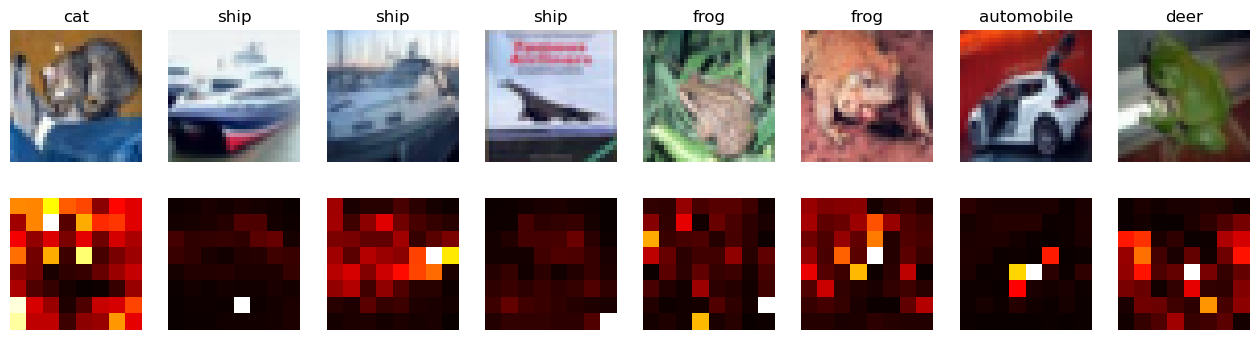

In [8]:
model.eval()
x, y = next(iter(test_loader))
x, y = x[:8].to(device), y[:8]

# Hook to capture attention weights from the last block
attn_weights = []

def hook_fn(module, input, output):
    with torch.no_grad():
        B, N, D = input[0].shape
        qkv = module.qkv(input[0]).reshape(B, N, 3, module.n_heads, module.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) / math.sqrt(module.head_dim)
        attn = attn.softmax(dim=-1)
        attn_weights.append(attn.cpu())

hook = model.blocks[-1].attn.register_forward_hook(hook_fn)

with torch.no_grad():
    preds = model(x).argmax(1).cpu()

hook.remove()

# Plot CLS attention maps
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
attn = attn_weights[0]  # (B, n_heads, N, N)
cls_attn = attn[:, :, 0, 1:].mean(dim=1)  # average over heads, CLS→patches: (B, 64)
cls_attn = cls_attn.reshape(-1, 8, 8)  # reshape to spatial grid

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    img = x[i].permute(1, 2, 0).cpu()
    img = (img - img.min()) / (img.max() - img.min())
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{classes[preds[i]]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(cls_attn[i], cmap='hot', interpolation='nearest')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Image')
axes[1, 0].set_ylabel('Attention')
